# 09 — Spatial Maps and Final Synthesis

This notebook maps the final vulnerability, clustering, and hidden-risk results across Florida counties.

It creates:

* the 2025 vulnerability-class map;
* the dominant recent profile map for 2021–2025;
* the hidden-risk and priority-county map;
* the final 15-county synthesis table.

All classifications, profiles, SHAP results, and hidden-risk selections were completed in earlier notebooks and are only loaded here.

## 2. Notebook Setup

Import libraries, define paths, and create the final output folders.

In [1]:
# ==================================================
# Imports
# ==================================================

from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# Project Paths
# ==================================================

PROJECT_ROOT = Path("..")

RAW_DATA = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

INTERIM_DATA = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "county_year_features"
)

CLUSTERING_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "vulnerability_clustering"
)

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "final_spatial_synthesis"
)

RESULTS_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "final_spatial_synthesis"
)

# ==================================================
# Input Files
# ==================================================

VULNERABILITY_DATA_PATH = (
    INTERIM_DATA
    / "county_year_vulnerability_scores.csv"
)

DOMINANT_RECENT_PROFILES_PATH = (
    CLUSTERING_TABLES
    / "dominant_recent_county_profiles_2021_2025.csv"
)

HIDDEN_RISK_ASSESSMENT_PATH = (
    CLUSTERING_TABLES
    / "county_hidden_risk_assessment.csv"
)

HIDDEN_RISK_SENSITIVITY_PATH = (
    CLUSTERING_TABLES
    / "hidden_risk_sensitivity_county_summary.csv"
)

SHAPEFILE_PATH = (
    RAW_DATA
    / "shapefiles"
    / "tl_2025_us_county"
    / "tl_2025_us_county.shp"
)

# ==================================================
# Output Folders
# ==================================================

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

# ==================================================
# Project Settings
# ==================================================

PROJECT_START_YEAR = 2011
PROJECT_END_YEAR = 2025

LATEST_YEAR = 2025

RECENT_START_YEAR = 2021
RECENT_END_YEAR = 2025

EXPECTED_FLORIDA_COUNTIES = 67

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="white")

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

print("Notebook setup complete.")
print(f"Vulnerability dataset: {VULNERABILITY_DATA_PATH}")
print(f"Dominant-profile table: {DOMINANT_RECENT_PROFILES_PATH}")
print(f"Hidden-risk assessment: {HIDDEN_RISK_ASSESSMENT_PATH}")
print(f"Hidden-risk sensitivity table: {HIDDEN_RISK_SENSITIVITY_PATH}")
print(f"Florida county shapefile: {SHAPEFILE_PATH}")
print(f"Final tables folder: {RESULTS_TABLES}")
print(f"Final figures folder: {RESULTS_FIGURES}")

Notebook setup complete.
Vulnerability dataset: ..\data\interim\county_year_features\county_year_vulnerability_scores.csv
Dominant-profile table: ..\results\tables\vulnerability_clustering\dominant_recent_county_profiles_2021_2025.csv
Hidden-risk assessment: ..\results\tables\vulnerability_clustering\county_hidden_risk_assessment.csv
Hidden-risk sensitivity table: ..\results\tables\vulnerability_clustering\hidden_risk_sensitivity_county_summary.csv
Florida county shapefile: ..\data\raw\shapefiles\tl_2025_us_county\tl_2025_us_county.shp
Final tables folder: ..\results\tables\final_spatial_synthesis
Final figures folder: ..\results\figures\final_spatial_synthesis


## 3. Load Final Spatial Inputs

Load the completed vulnerability, cluster-profile, hidden-risk, sensitivity, and Florida geometry outputs.

In [2]:
# ==================================================
# Step 3: Load Final Spatial Inputs
# ==================================================

required_paths = {
    "Vulnerability dataset": VULNERABILITY_DATA_PATH,
    "Dominant recent profiles": DOMINANT_RECENT_PROFILES_PATH,
    "Hidden-risk assessment": HIDDEN_RISK_ASSESSMENT_PATH,
    "Hidden-risk sensitivity summary": HIDDEN_RISK_SENSITIVITY_PATH,
    "Florida county shapefile": SHAPEFILE_PATH
}

# --------------------------------------------------
# Confirm Required Files Exist
# --------------------------------------------------

missing_files = {
    name: path
    for name, path in required_paths.items()
    if not path.exists()
}

if missing_files:
    print("Missing required files:")

    for name, path in missing_files.items():
        print(f"- {name}: {path}")

    raise FileNotFoundError(
        "One or more required spatial inputs could not be located."
    )

# --------------------------------------------------
# Load Completed Analytical Outputs
# --------------------------------------------------

vulnerability_data = pd.read_csv(
    VULNERABILITY_DATA_PATH
)

dominant_recent_profiles = pd.read_csv(
    DOMINANT_RECENT_PROFILES_PATH
)

hidden_risk_assessment = pd.read_csv(
    HIDDEN_RISK_ASSESSMENT_PATH
)

hidden_risk_sensitivity = pd.read_csv(
    HIDDEN_RISK_SENSITIVITY_PATH
)

# --------------------------------------------------
# Load Florida County Geometry
# --------------------------------------------------

county_shapes = gpd.read_file(
    SHAPEFILE_PATH
)

florida_shapes = (
    county_shapes[
        county_shapes["STATEFP"].astype(str).str.zfill(2) == "12"
    ]
    .copy()
)

# --------------------------------------------------
# Loading Summary
# --------------------------------------------------

loading_summary = pd.DataFrame({
    "dataset": [
        "County-year vulnerability data",
        "Dominant recent profiles",
        "Hidden-risk assessment",
        "Hidden-risk sensitivity summary",
        "Florida county geometry"
    ],
    "rows": [
        len(vulnerability_data),
        len(dominant_recent_profiles),
        len(hidden_risk_assessment),
        len(hidden_risk_sensitivity),
        len(florida_shapes)
    ],
    "columns": [
        vulnerability_data.shape[1],
        dominant_recent_profiles.shape[1],
        hidden_risk_assessment.shape[1],
        hidden_risk_sensitivity.shape[1],
        florida_shapes.shape[1]
    ]
})

print("Final spatial inputs loaded successfully.")
print(f"Florida geometry CRS: {florida_shapes.crs}")

display(loading_summary)

Final spatial inputs loaded successfully.
Florida geometry CRS: EPSG:4269


,dataset,rows,columns
0,County-year vulnerability data,1000,123
1,Dominant recent profiles,67,8
2,Hidden-risk assessment,67,27
3,Hidden-risk sensitivity summary,67,12
4,Florida county geometry,67,19


## 4. Validate County Matching

Standardize county FIPS and confirm complete matching across the final spatial inputs.

In [3]:
# ==================================================
# Step 4: Validate County Matching
# ==================================================

def standardize_fips(series):
    return (
        series
        .astype("string")
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(5)
    )


# ==================================================
# Standardize County FIPS
# ==================================================

vulnerability_data["STCOFIPS"] = standardize_fips(
    vulnerability_data["STCOFIPS"]
)

dominant_recent_profiles["STCOFIPS"] = standardize_fips(
    dominant_recent_profiles["STCOFIPS"]
)

hidden_risk_assessment["STCOFIPS"] = standardize_fips(
    hidden_risk_assessment["STCOFIPS"]
)

hidden_risk_sensitivity["STCOFIPS"] = standardize_fips(
    hidden_risk_sensitivity["STCOFIPS"]
)

florida_shapes["STCOFIPS"] = standardize_fips(
    florida_shapes["GEOID"]
)


# ==================================================
# Extract Latest-Year Vulnerability Results
# ==================================================

latest_vulnerability = (
    vulnerability_data[
        vulnerability_data["Year"] == LATEST_YEAR
    ]
    .copy()
)

latest_vulnerability = latest_vulnerability[
    [
        "STCOFIPS",
        "RegionName",
        "Year",
        "climate_housing_vulnerability_score",
        "vulnerability_class"
    ]
]


# ==================================================
# Check Required Columns
# ==================================================

required_columns = {
    "Latest vulnerability": [
        "STCOFIPS",
        "RegionName",
        "Year",
        "climate_housing_vulnerability_score",
        "vulnerability_class"
    ],
    "Dominant recent profiles": [
        "STCOFIPS",
        "RegionName",
        "dominant_recent_cluster_name",
        "dominant_profile_persistence_pct"
    ],
    "Hidden-risk assessment": [
        "STCOFIPS",
        "RegionName",
        "recent_avg_annual_growth_pct",
        "recent_avg_vulnerability_score",
        "risk_cluster_share_pct",
        "hidden_risk_category"
    ],
    "Sensitivity summary": [
        "STCOFIPS",
        "RegionName",
        "scenarios_selected",
        "selection_rate_pct"
    ],
    "Florida geometry": [
        "STCOFIPS",
        "NAME",
        "geometry"
    ]
}

datasets = {
    "Latest vulnerability": latest_vulnerability,
    "Dominant recent profiles": dominant_recent_profiles,
    "Hidden-risk assessment": hidden_risk_assessment,
    "Sensitivity summary": hidden_risk_sensitivity,
    "Florida geometry": florida_shapes
}

missing_required_columns = {}

for dataset_name, columns in required_columns.items():
    missing = [
        column
        for column in columns
        if column not in datasets[dataset_name].columns
    ]

    if missing:
        missing_required_columns[dataset_name] = missing

if missing_required_columns:
    print("Missing required columns:")

    for dataset_name, columns in missing_required_columns.items():
        print(f"- {dataset_name}: {columns}")

    raise KeyError(
        "One or more required columns are unavailable."
    )


# ==================================================
# Create County-Matching Audit
# ==================================================

geometry_fips = set(
    florida_shapes["STCOFIPS"].dropna()
)

audit_rows = []

for dataset_name, dataset in datasets.items():

    dataset_fips = set(
        dataset["STCOFIPS"].dropna()
    )

    audit_rows.append({
        "dataset": dataset_name,
        "rows": len(dataset),
        "unique_counties": dataset["STCOFIPS"].nunique(),
        "duplicate_fips": dataset["STCOFIPS"].duplicated().sum(),
        "missing_fips": dataset["STCOFIPS"].isna().sum(),
        "not_in_geometry": len(dataset_fips - geometry_fips),
        "missing_from_dataset": len(geometry_fips - dataset_fips)
    })

county_matching_audit = pd.DataFrame(
    audit_rows
)


# ==================================================
# Geometry Quality Checks
# ==================================================

invalid_geometry_count = (
    ~florida_shapes.geometry.is_valid
).sum()

empty_geometry_count = (
    florida_shapes.geometry.is_empty
).sum()

print("County matching audit completed.")
print(f"Latest vulnerability year: {LATEST_YEAR}")
print(f"Florida counties expected: {EXPECTED_FLORIDA_COUNTIES}")
print(f"Invalid geometries: {invalid_geometry_count}")
print(f"Empty geometries: {empty_geometry_count}")

display(county_matching_audit)


# ==================================================
# Stop if Matching Problems Are Detected
# ==================================================

audit_problem_columns = [
    "duplicate_fips",
    "missing_fips",
    "not_in_geometry",
    "missing_from_dataset"
]

if (
    county_matching_audit[audit_problem_columns]
    .to_numpy()
    .sum()
    > 0
):
    raise ValueError(
        "County matching problems were detected."
    )

if (
    latest_vulnerability["STCOFIPS"].nunique()
    != EXPECTED_FLORIDA_COUNTIES
):
    raise ValueError(
        "The latest-year vulnerability data does not contain 67 counties."
    )

print("\nAll final spatial inputs match the 67 Florida counties.")

County matching audit completed.
Latest vulnerability year: 2025
Florida counties expected: 67
Invalid geometries: 0
Empty geometries: 0


,dataset,rows,unique_counties,duplicate_fips,missing_fips,not_in_geometry,missing_from_dataset
0,Latest vulnerability,67,67,0,0,0,0
1,Dominant recent profiles,67,67,0,0,0,0
2,Hidden-risk assessment,67,67,0,0,0,0
3,Sensitivity summary,67,67,0,0,0,0
4,Florida geometry,67,67,0,0,0,0



All final spatial inputs match the 67 Florida counties.


## 5. Build the Final Spatial Dataset

Combine the completed county-level results into one GeoDataFrame for mapping and synthesis.

In [4]:
# ==================================================
# Step 5: Build the Final Spatial Dataset
# ==================================================

# --------------------------------------------------
# Select Required Fields
# --------------------------------------------------

geometry_base = (
    florida_shapes[
        [
            "STCOFIPS",
            "NAME",
            "geometry"
        ]
    ]
    .rename(
        columns={
            "NAME": "geometry_county_name"
        }
    )
    .copy()
)

latest_for_merge = (
    latest_vulnerability[
        [
            "STCOFIPS",
            "RegionName",
            "Year",
            "climate_housing_vulnerability_score",
            "vulnerability_class"
        ]
    ]
    .rename(
        columns={
            "RegionName": "county_name",
            "Year": "latest_year",
            "climate_housing_vulnerability_score":
                "latest_vulnerability_score",
            "vulnerability_class":
                "latest_vulnerability_class"
        }
    )
    .copy()
)

profiles_for_merge = (
    dominant_recent_profiles[
        [
            "STCOFIPS",
            "dominant_recent_cluster_name",
            "dominant_profile_persistence_pct"
        ]
    ]
    .copy()
)

hidden_risk_for_merge = (
    hidden_risk_assessment[
        [
            "STCOFIPS",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "risk_cluster_share_pct",
            "hidden_risk_category"
        ]
    ]
    .copy()
)

sensitivity_for_merge = (
    hidden_risk_sensitivity[
        [
            "STCOFIPS",
            "scenarios_selected",
            "selection_rate_pct"
        ]
    ]
    .copy()
)


# ==================================================
# Merge Final County-Level Results
# ==================================================

final_spatial_data = (
    geometry_base
    .merge(
        latest_for_merge,
        on="STCOFIPS",
        how="left",
        validate="one_to_one"
    )
    .merge(
        profiles_for_merge,
        on="STCOFIPS",
        how="left",
        validate="one_to_one"
    )
    .merge(
        hidden_risk_for_merge,
        on="STCOFIPS",
        how="left",
        validate="one_to_one"
    )
    .merge(
        sensitivity_for_merge,
        on="STCOFIPS",
        how="left",
        validate="one_to_one"
    )
)

final_spatial_data = gpd.GeoDataFrame(
    final_spatial_data,
    geometry="geometry",
    crs=florida_shapes.crs
)


# ==================================================
# Project Geometry for Florida Mapping
# ==================================================

MAPPING_CRS = "EPSG:3086"

final_spatial_data = final_spatial_data.to_crs(
    MAPPING_CRS
)


# ==================================================
# Validate Final Spatial Dataset
# ==================================================

required_mapping_fields = [
    "latest_vulnerability_score",
    "latest_vulnerability_class",
    "dominant_recent_cluster_name",
    "dominant_profile_persistence_pct",
    "recent_avg_annual_growth_pct",
    "recent_avg_vulnerability_score",
    "risk_cluster_share_pct",
    "hidden_risk_category",
    "scenarios_selected",
    "selection_rate_pct",
    "geometry"
]

missing_mapping_values = (
    final_spatial_data[required_mapping_fields]
    .isna()
    .sum()
    .rename("missing_values")
    .reset_index()
    .rename(columns={"index": "field"})
)

if len(final_spatial_data) != EXPECTED_FLORIDA_COUNTIES:
    raise ValueError(
        "The final spatial dataset does not contain 67 counties."
    )

if final_spatial_data["STCOFIPS"].duplicated().any():
    raise ValueError(
        "Duplicate county FIPS values were found after merging."
    )

if missing_mapping_values["missing_values"].sum() > 0:
    display(missing_mapping_values)

    raise ValueError(
        "Missing values were found in required mapping fields."
    )


# ==================================================
# Final Dataset Summary
# ==================================================

print("Final county-level spatial dataset created.")
print(f"Rows: {len(final_spatial_data)}")
print(
    "Unique counties: "
    f"{final_spatial_data['STCOFIPS'].nunique()}"
)
print(f"Mapping CRS: {final_spatial_data.crs}")
print(
    "Missing required mapping values: "
    f"{missing_mapping_values['missing_values'].sum()}"
)

print("\n2025 vulnerability-class distribution")
display(
    final_spatial_data[
        "latest_vulnerability_class"
    ]
    .value_counts()
    .rename_axis("vulnerability_class")
    .reset_index(name="count")
)

print("\nDominant recent profile distribution")
display(
    final_spatial_data[
        "dominant_recent_cluster_name"
    ]
    .value_counts()
    .rename_axis("dominant_recent_profile")
    .reset_index(name="count")
)

print("\nHidden-risk category distribution")
display(
    final_spatial_data[
        "hidden_risk_category"
    ]
    .value_counts()
    .rename_axis("hidden_risk_category")
    .reset_index(name="count")
)

print("\nSensitivity-selection distribution")
display(
    final_spatial_data[
        "scenarios_selected"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("scenarios_selected")
    .reset_index(name="county_count")
)

Final county-level spatial dataset created.
Rows: 67
Unique counties: 67
Mapping CRS: EPSG:3086
Missing required mapping values: 0

2025 vulnerability-class distribution


,vulnerability_class,count
0,Low,29
1,Medium,24
2,High,14



Dominant recent profile distribution


,dominant_recent_profile,count
0,Disaster-Loss Growth Pressure,30
1,Socioeconomic Resilience Stress,22
2,Lower-Stress Resilient Profile,11
3,High-Exposure Latent Risk,4



Hidden-risk category distribution


,hidden_risk_category,count
0,Other County,52
1,Hidden Risk,9
2,Priority Hidden Risk,6



Sensitivity-selection distribution


,scenarios_selected,county_count
0,0,52
1,2,1
2,4,3
3,5,5
4,7,2
5,8,4


## 6. Map 2025 Vulnerability Class

Map the latest Low, Medium, and High climate-housing vulnerability classes across Florida counties.

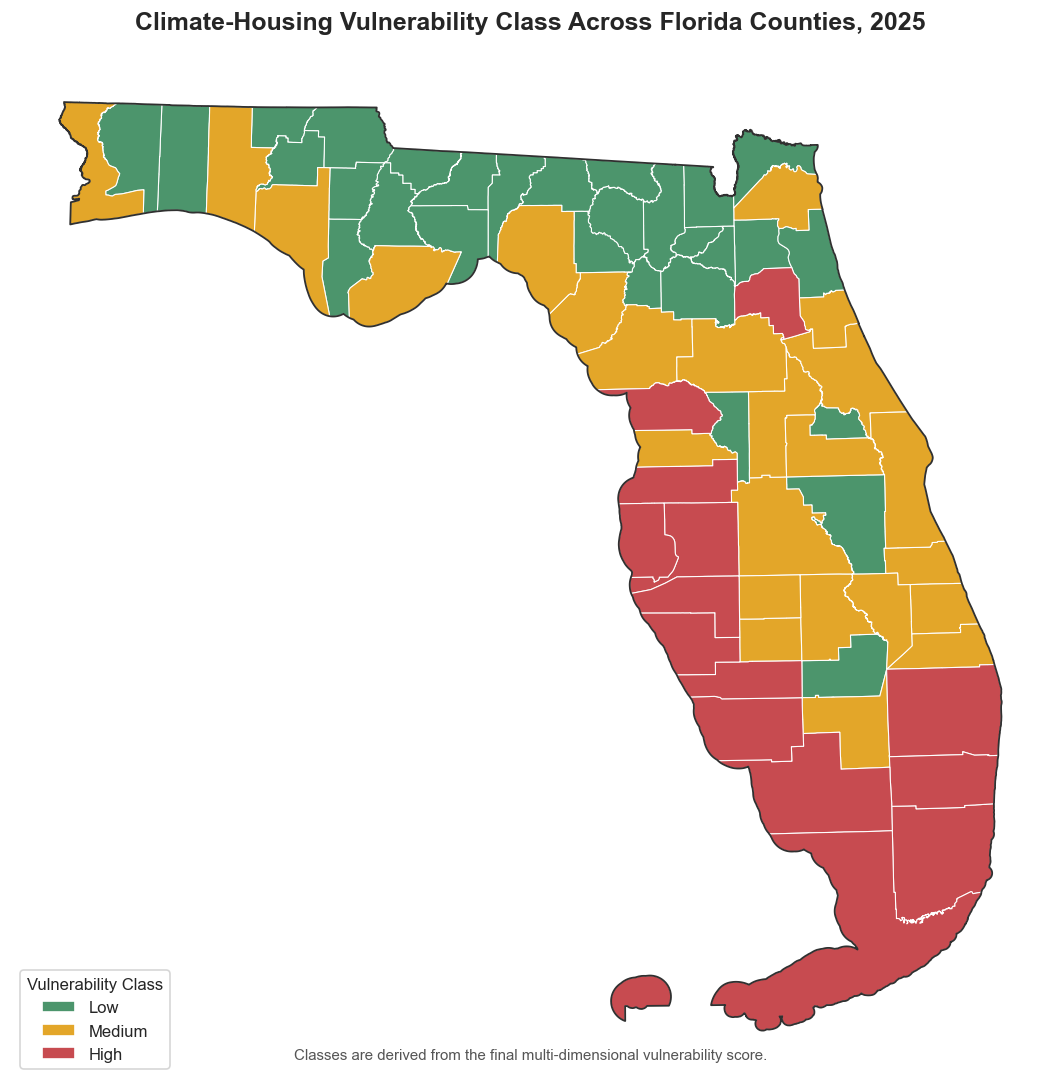

2025 vulnerability-class map created.
Saved to: ..\results\figures\final_spatial_synthesis\florida_vulnerability_class_2025.png


In [5]:
# ==================================================
# Step 6: Map 2025 Vulnerability Class
# ==================================================

from matplotlib.patches import Patch

# --------------------------------------------------
# Category Order and Colours
# --------------------------------------------------

vulnerability_order = [
    "Low",
    "Medium",
    "High"
]

vulnerability_colors = {
    "Low": "#4C956C",
    "Medium": "#E3A629",
    "High": "#C74B50"
}

unexpected_classes = set(
    final_spatial_data[
        "latest_vulnerability_class"
    ].dropna().unique()
) - set(vulnerability_order)

if unexpected_classes:
    raise ValueError(
        "Unexpected vulnerability classes found: "
        f"{sorted(unexpected_classes)}"
    )


# ==================================================
# Create Map
# ==================================================

fig, ax = plt.subplots(
    figsize=(9, 10)
)

for vulnerability_class in vulnerability_order:

    class_data = final_spatial_data[
        final_spatial_data[
            "latest_vulnerability_class"
        ] == vulnerability_class
    ]

    class_data.plot(
        ax=ax,
        color=vulnerability_colors[
            vulnerability_class
        ],
        edgecolor="white",
        linewidth=0.65
    )

# Add a clear external state boundary
final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=1.1
)

ax.set_title(
    "Climate-Housing Vulnerability Class "
    "Across Florida Counties, 2025",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    0.015,
    (
        "Classes are derived from the final "
        "multi-dimensional vulnerability score."
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=9,
    color="#555555"
)

legend_handles = [
    Patch(
        facecolor=vulnerability_colors[
            vulnerability_class
        ],
        edgecolor="white",
        label=vulnerability_class
    )
    for vulnerability_class in vulnerability_order
]

ax.legend(
    handles=legend_handles,
    title="Vulnerability Class",
    loc="lower left",
    frameon=True,
    fontsize=10,
    title_fontsize=10
)

ax.set_axis_off()

plt.tight_layout()


# ==================================================
# Save Figure
# ==================================================

vulnerability_map_path = (
    RESULTS_FIGURES
    / "florida_vulnerability_class_2025.png"
)

plt.savefig(
    vulnerability_map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("2025 vulnerability-class map created.")
print(f"Saved to: {vulnerability_map_path}")

### Interpretation

Climate-housing vulnerability was spatially uneven across Florida in 2025. Of the 67 counties, 29 were classified as Low vulnerability, 24 as Medium, and 14 as High.

Low vulnerability was concentrated mainly across northern Florida, while High vulnerability was more common in southern Florida and along parts of the southwest Gulf Coast. However, elevated vulnerability was not limited to coastal counties, indicating that socioeconomic, affordability, resilience, disaster, insurance-loss, and housing-market conditions also contributed to the final classifications.

The map represents vulnerability severity in 2025. It does not identify the specific vulnerability pathway affecting each county, which is examined through the recent cluster-profile map.

## 7. Map Dominant Recent Vulnerability Profiles

Map the vulnerability profile that most frequently characterized each county during 2021–2025.

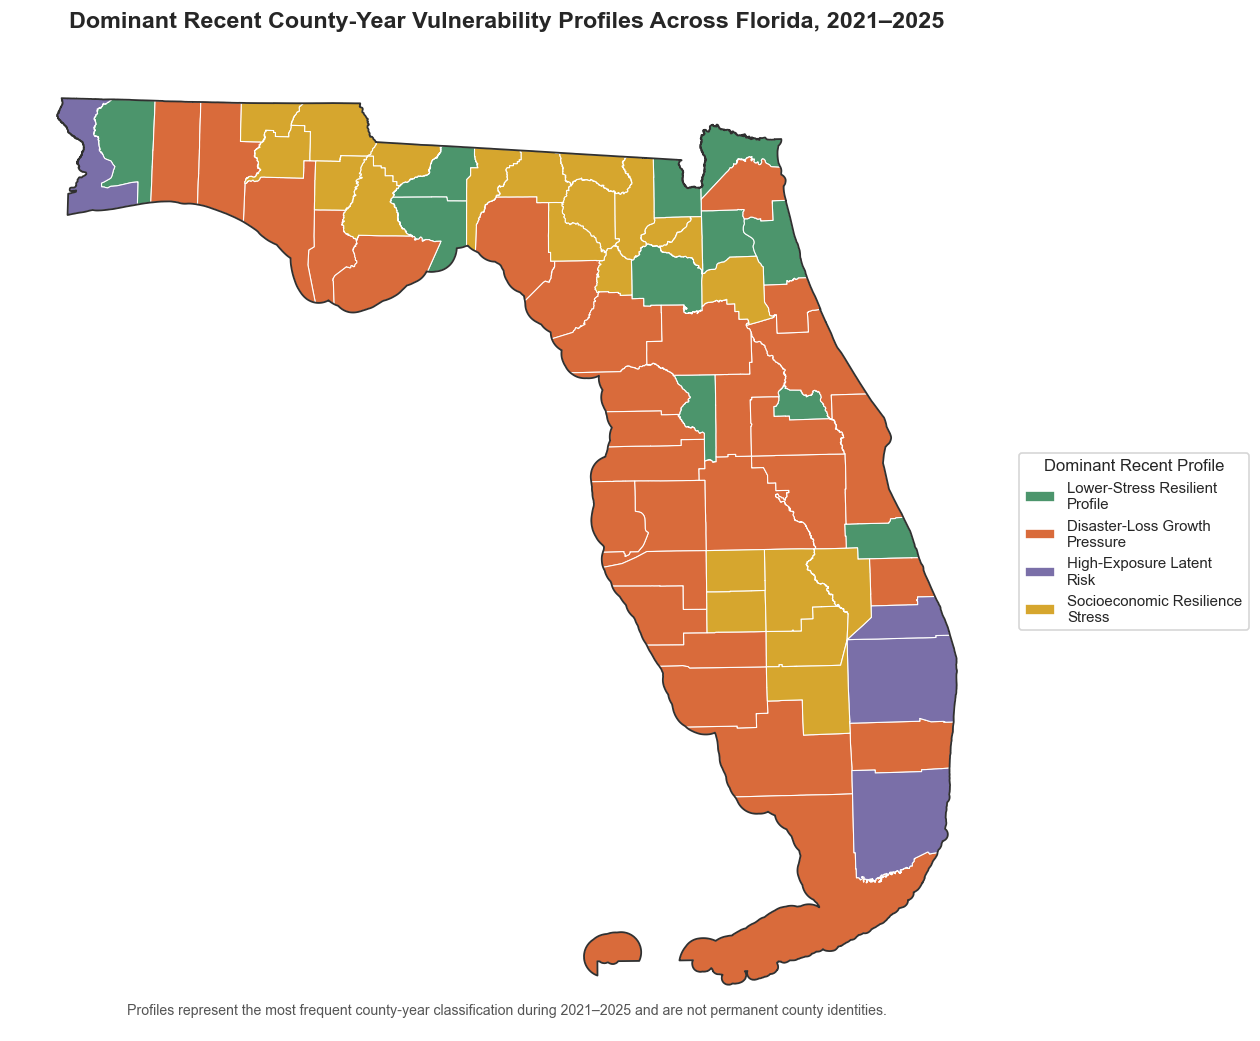

Dominant recent vulnerability-profile map created.
Saved to: ..\results\figures\final_spatial_synthesis\florida_dominant_recent_profile_2021_2025.png


In [6]:
# ==================================================
# Step 7: Map Dominant Recent Vulnerability Profiles
# ==================================================

from matplotlib.patches import Patch

# --------------------------------------------------
# Profile Order, Labels, and Colours
# --------------------------------------------------

profile_order = [
    "Lower-Stress Resilient Profile",
    "Disaster-Loss Growth Pressure",
    "High-Exposure Latent Risk",
    "Socioeconomic Resilience Stress"
]

profile_colors = {
    "Lower-Stress Resilient Profile": "#4C956C",
    "Disaster-Loss Growth Pressure": "#D96B3B",
    "High-Exposure Latent Risk": "#7A6FA8",
    "Socioeconomic Resilience Stress": "#D6A62E"
}

profile_legend_labels = {
    "Lower-Stress Resilient Profile":
        "Lower-Stress Resilient\nProfile",
    "Disaster-Loss Growth Pressure":
        "Disaster-Loss Growth\nPressure",
    "High-Exposure Latent Risk":
        "High-Exposure Latent\nRisk",
    "Socioeconomic Resilience Stress":
        "Socioeconomic Resilience\nStress"
}

unexpected_profiles = set(
    final_spatial_data[
        "dominant_recent_cluster_name"
    ].dropna().unique()
) - set(profile_order)

if unexpected_profiles:
    raise ValueError(
        "Unexpected cluster profiles found: "
        f"{sorted(unexpected_profiles)}"
    )


# ==================================================
# Create Map
# ==================================================

fig, ax = plt.subplots(
    figsize=(10.5, 10)
)

for profile_name in profile_order:

    profile_data = final_spatial_data[
        final_spatial_data[
            "dominant_recent_cluster_name"
        ] == profile_name
    ]

    profile_data.plot(
        ax=ax,
        color=profile_colors[profile_name],
        edgecolor="white",
        linewidth=0.65
    )

# Add external Florida boundary
final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=1.1
)

ax.set_title(
    "Dominant Recent County-Year Vulnerability "
    "Profiles Across Florida, 2021–2025",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    0.012,
    (
        "Profiles represent the most frequent county-year "
        "classification during 2021–2025 and are not "
        "permanent county identities."
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#555555"
)

legend_handles = [
    Patch(
        facecolor=profile_colors[profile_name],
        edgecolor="white",
        label=profile_legend_labels[profile_name]
    )
    for profile_name in profile_order
]

ax.legend(
    handles=legend_handles,
    title="Dominant Recent Profile",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

ax.set_axis_off()

plt.tight_layout()


# ==================================================
# Save Figure
# ==================================================

profile_map_path = (
    RESULTS_FIGURES
    / "florida_dominant_recent_profile_2021_2025.png"
)

plt.savefig(
    profile_map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Dominant recent vulnerability-profile map created.")
print(f"Saved to: {profile_map_path}")

### Interpretation

Recent vulnerability profiles varied substantially across Florida. Disaster-Loss Growth Pressure was the most common dominant profile, characterizing 30 counties, followed by Socioeconomic Resilience Stress in 22 counties.

The spatial pattern shows that vulnerability can emerge through different combinations of housing growth, disaster losses, exposure, socioeconomic conditions, and resilience. Lower-Stress Resilient counties were geographically scattered, while High-Exposure Latent Risk was concentrated in only four counties.

These profiles summarize the most frequent county-year conditions during 2021–2025 and should not be interpreted as permanent county identities.

## 8. Map Hidden-Risk and Priority Counties

Map the 15 hidden-risk counties and highlight the six sensitivity-robust priority counties.

Priority hidden-risk counties


,county_name,scenarios_selected,selection_rate_pct
0,Collier County,8,100.0000
1,Hernando County,8,100.0000
2,Miami-Dade County,8,100.0000
3,Monroe County,8,100.0000
4,Dixie County,7,87.5000
5,Levy County,7,87.5000


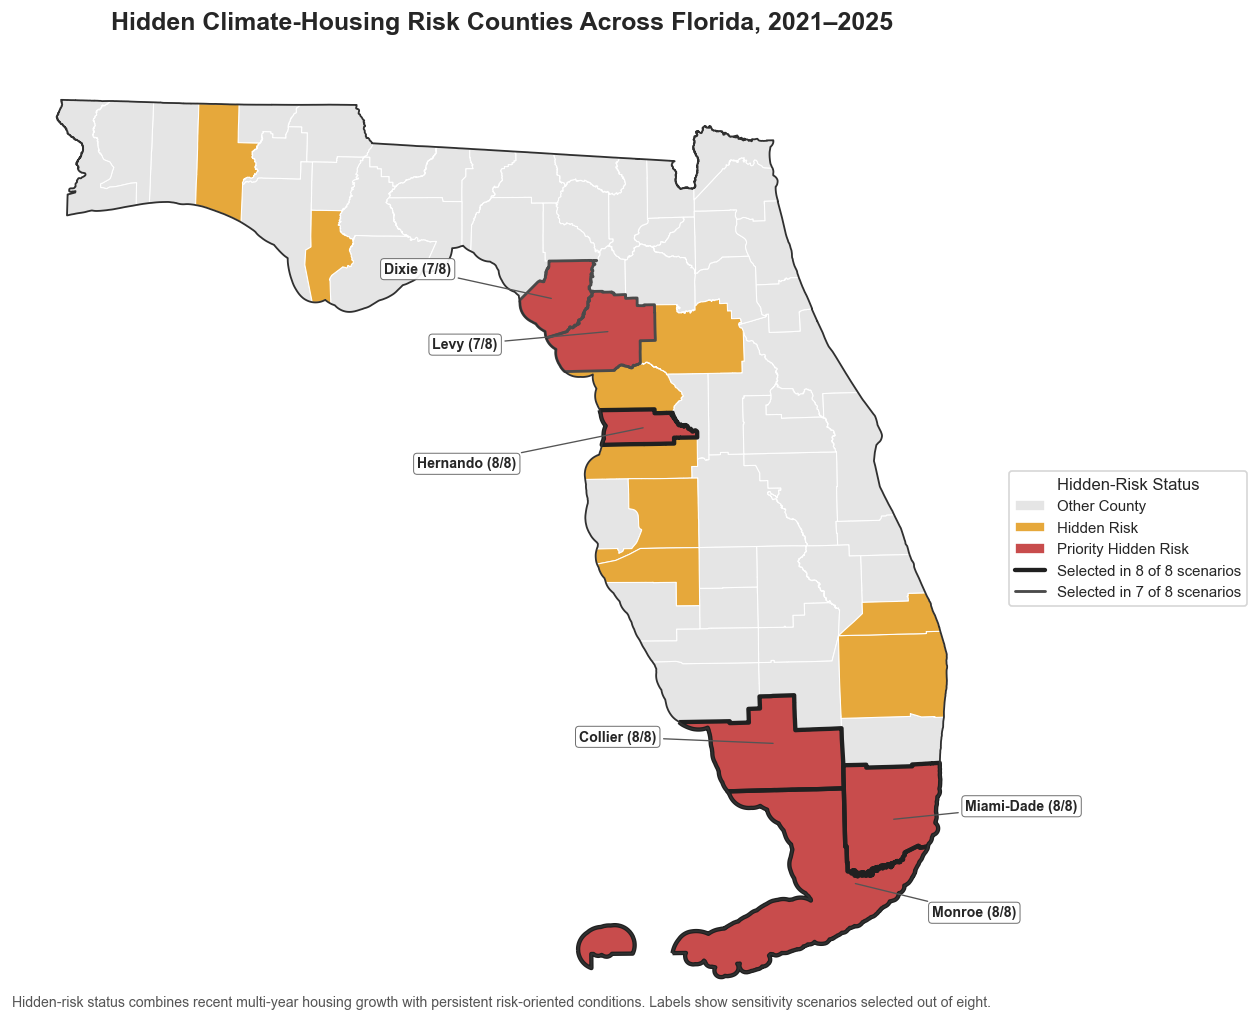

Hidden-risk and priority-county map created.
Saved to: ..\results\figures\final_spatial_synthesis\florida_hidden_risk_priority_counties_2021_2025.png


In [7]:
# ==================================================
# Step 8: Map Hidden-Risk and Priority Counties
# ==================================================

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --------------------------------------------------
# Category Order and Colours
# --------------------------------------------------

hidden_risk_order = [
    "Other County",
    "Hidden Risk",
    "Priority Hidden Risk"
]

hidden_risk_colors = {
    "Other County": "#E5E5E5",
    "Hidden Risk": "#E6A83B",
    "Priority Hidden Risk": "#C84C4C"
}

unexpected_categories = set(
    final_spatial_data[
        "hidden_risk_category"
    ].dropna().unique()
) - set(hidden_risk_order)

if unexpected_categories:
    raise ValueError(
        "Unexpected hidden-risk categories found: "
        f"{sorted(unexpected_categories)}"
    )


# ==================================================
# Validate Priority Counties
# ==================================================

priority_counties = (
    final_spatial_data[
        final_spatial_data[
            "hidden_risk_category"
        ] == "Priority Hidden Risk"
    ]
    .copy()
)

if len(priority_counties) != 6:
    raise ValueError(
        "The priority hidden-risk group does not contain six counties."
    )

priority_counties["label_name"] = (
    priority_counties["county_name"]
    .str.replace(" County", "", regex=False)
)

print("Priority hidden-risk counties")
display(
    priority_counties[
        [
            "county_name",
            "scenarios_selected",
            "selection_rate_pct"
        ]
    ]
    .sort_values(
        ["scenarios_selected", "county_name"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)


# ==================================================
# Create Map
# ==================================================

fig, ax = plt.subplots(
    figsize=(10.5, 10)
)

# Plot the three hidden-risk categories
for category in hidden_risk_order:

    category_data = final_spatial_data[
        final_spatial_data[
            "hidden_risk_category"
        ] == category
    ]

    category_data.plot(
        ax=ax,
        color=hidden_risk_colors[category],
        edgecolor="white",
        linewidth=0.65
    )

# Add sensitivity-robust outlines
selected_all_eight = final_spatial_data[
    final_spatial_data["scenarios_selected"] == 8
]

selected_seven = final_spatial_data[
    final_spatial_data["scenarios_selected"] == 7
]

selected_all_eight.boundary.plot(
    ax=ax,
    color="#202020",
    linewidth=2.6
)

selected_seven.boundary.plot(
    ax=ax,
    color="#4A4A4A",
    linewidth=1.7
)

# Add external Florida boundary
final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=1.1
)


# ==================================================
# Label the Six Priority Counties
# ==================================================

label_offsets = {
    "Dixie": (-62, 18),
    "Levy": (-68, -8),
    "Hernando": (-78, -22),
    "Collier": (-72, 4),
    "Miami-Dade": (45, 8),
    "Monroe": (48, -18)
}

priority_label_points = priority_counties.copy()
priority_label_points["label_geometry"] = (
    priority_label_points.geometry.representative_point()
)

for _, row in priority_label_points.iterrows():

    county_label = row["label_name"]
    label_point = row["label_geometry"]

    offset = label_offsets.get(
        county_label,
        (35, 10)
    )

    ax.annotate(
        text=(
            f"{county_label} "
            f"({int(row['scenarios_selected'])}/8)"
        ),
        xy=(label_point.x, label_point.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=8.5,
        fontweight="bold",
        ha="left" if offset[0] > 0 else "right",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "#666666",
            "linewidth": 0.6,
            "alpha": 0.92
        },
        arrowprops={
            "arrowstyle": "-",
            "color": "#555555",
            "linewidth": 0.8
        }
    )


# ==================================================
# Titles and Legend
# ==================================================

ax.set_title(
    "Hidden Climate-Housing Risk Counties "
    "Across Florida, 2021–2025",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    0.012,
    (
        "Hidden-risk status combines recent multi-year housing growth "
        "with persistent risk-oriented conditions. "
        "Labels show sensitivity scenarios selected out of eight."
    ),
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#555555"
)

legend_handles = [
    Patch(
        facecolor=hidden_risk_colors["Other County"],
        edgecolor="white",
        label="Other County"
    ),
    Patch(
        facecolor=hidden_risk_colors["Hidden Risk"],
        edgecolor="white",
        label="Hidden Risk"
    ),
    Patch(
        facecolor=hidden_risk_colors["Priority Hidden Risk"],
        edgecolor="white",
        label="Priority Hidden Risk"
    ),
    Line2D(
        [0],
        [0],
        color="#202020",
        linewidth=2.6,
        label="Selected in 8 of 8 scenarios"
    ),
    Line2D(
        [0],
        [0],
        color="#4A4A4A",
        linewidth=1.7,
        label="Selected in 7 of 8 scenarios"
    )
]

ax.legend(
    handles=legend_handles,
    title="Hidden-Risk Status",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

ax.set_axis_off()

plt.tight_layout()


# ==================================================
# Save Figure
# ==================================================

hidden_risk_map_path = (
    RESULTS_FIGURES
    / "florida_hidden_risk_priority_counties_2021_2025.png"
)

plt.savefig(
    hidden_risk_map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Hidden-risk and priority-county map created.")
print(f"Saved to: {hidden_risk_map_path}")

### Interpretation

Fifteen Florida counties were identified as hidden risk, including six priority counties. Hernando, Collier, Monroe, and Miami-Dade were selected in all eight sensitivity scenarios, while Dixie and Levy were selected in seven.

The priority counties span South Florida and several parts of the Gulf Coast, showing that hidden climate-housing risk is not confined to one region. Additional hidden-risk counties also appear across the Panhandle, central Florida, and the southeastern coast.

These results identify counties where strong recent housing growth coexisted with persistent risk-oriented conditions during 2021–2025. Hidden-risk status therefore reflects multi-year market and vulnerability evidence rather than only the 2025 vulnerability class.

## 9. Final Hidden-Risk County Summary

Summarize the recent growth, vulnerability, profile, and sensitivity evidence for the 15 hidden-risk counties.

In [9]:
# ==================================================
# Step 9: Final Hidden-Risk County Summary
# ==================================================

hidden_risk_summary = (
    final_spatial_data[
        final_spatial_data[
            "hidden_risk_category"
        ].isin(
            [
                "Hidden Risk",
                "Priority Hidden Risk"
            ]
        )
    ]
    [
        [
            "county_name",
            "hidden_risk_category",
            "recent_avg_annual_growth_pct",
            "recent_avg_vulnerability_score",
            "latest_vulnerability_class",
            "dominant_recent_cluster_name",
            "risk_cluster_share_pct",
            "scenarios_selected",
            "selection_rate_pct"
        ]
    ]
    .copy()
)


# ==================================================
# Rename Report Columns
# ==================================================

hidden_risk_summary = hidden_risk_summary.rename(
    columns={
        "county_name": "County",
        "hidden_risk_category": "Hidden-Risk Status",
        "recent_avg_annual_growth_pct":
            "Recent Average Growth (%)",
        "recent_avg_vulnerability_score":
            "Recent Average Vulnerability",
        "latest_vulnerability_class":
            "2025 Vulnerability Class",
        "dominant_recent_cluster_name":
            "Dominant Recent Profile",
        "risk_cluster_share_pct":
            "Risk-Profile Persistence (%)",
        "scenarios_selected":
            "Scenarios Selected",
        "selection_rate_pct":
            "Selection Rate (%)"
    }
)


# ==================================================
# Sort Priority and Robust Counties First
# ==================================================

status_order = {
    "Priority Hidden Risk": 0,
    "Hidden Risk": 1
}

hidden_risk_summary["_status_order"] = (
    hidden_risk_summary[
        "Hidden-Risk Status"
    ].map(status_order)
)

hidden_risk_summary = (
    hidden_risk_summary
    .sort_values(
        [
            "_status_order",
            "Scenarios Selected",
            "Recent Average Growth (%)",
            "County"
        ],
        ascending=[
            True,
            False,
            False,
            True
        ]
    )
    .drop(columns="_status_order")
    .reset_index(drop=True)
)


# ==================================================
# Validate Final Table
# ==================================================

if len(hidden_risk_summary) != 15:
    raise ValueError(
        "The final hidden-risk summary does not contain 15 counties."
    )

priority_count = (
    hidden_risk_summary[
        "Hidden-Risk Status"
    ]
    .eq("Priority Hidden Risk")
    .sum()
)

if priority_count != 6:
    raise ValueError(
        "The final summary does not contain six priority counties."
    )



# ==================================================
# Display Report-Ready Table
# ==================================================

display_hidden_risk_summary = (
    hidden_risk_summary
    .copy()
)

# Mark the six priority counties clearly
display_hidden_risk_summary["County"] = np.where(
    display_hidden_risk_summary[
        "Hidden-Risk Status"
    ].eq("Priority Hidden Risk"),
    "★ " + display_hidden_risk_summary["County"],
    display_hidden_risk_summary["County"]
)

# Round numeric fields for notebook display
display_hidden_risk_summary[
    "Recent Average Growth (%)"
] = display_hidden_risk_summary[
    "Recent Average Growth (%)"
].round(2)

display_hidden_risk_summary[
    "Recent Average Vulnerability"
] = display_hidden_risk_summary[
    "Recent Average Vulnerability"
].round(4)

display_hidden_risk_summary[
    "Risk-Profile Persistence (%)"
] = display_hidden_risk_summary[
    "Risk-Profile Persistence (%)"
].round(1)

display_hidden_risk_summary[
    "Selection Rate (%)"
] = display_hidden_risk_summary[
    "Selection Rate (%)"
].round(1)

print("Final hidden-risk county summary created.")
print(f"Hidden-risk counties: {len(hidden_risk_summary)}")
print(f"Priority counties: {priority_count}")
print("★ indicates a priority hidden-risk county.")

display(
    display_hidden_risk_summary
)


# ==================================================
# Save Final Table
# ==================================================

hidden_risk_summary_path = (
    RESULTS_TABLES
    / "final_hidden_risk_county_summary.csv"
)

hidden_risk_summary.to_csv(
    hidden_risk_summary_path,
    index=False
)

print(f"Saved to: {hidden_risk_summary_path}")

Final hidden-risk county summary created.
Hidden-risk counties: 15
Priority counties: 6
★ indicates a priority hidden-risk county.


,County,Hidden-Risk Status,Recent Average Growth (%),Recent Average Vulnerability,2025 Vulnerability Class,Dominant Recent Profile,Risk-Profile Persistence (%),Scenarios Selected,Selection Rate (%)
0,★ Hernando County,Priority Hidden Risk,10.8200,0.5955,Medium,Disaster-Loss Growth Pressure,100.0000,8,100.0000
1,★ Collier County,Priority Hidden Risk,10.5300,0.6297,High,Disaster-Loss Growth Pressure,100.0000,8,100.0000
2,★ Monroe County,Priority Hidden Risk,10.0500,0.6352,High,Disaster-Loss Growth Pressure,100.0000,8,100.0000
3,★ Miami-Dade County,Priority Hidden Risk,10.0300,0.6483,High,High-Exposure Latent Risk,100.0000,8,100.0000
4,★ Dixie County,Priority Hidden Risk,9.8200,0.5695,Medium,Disaster-Loss Growth Pressure,80.0000,7,87.5000
5,★ Levy County,Priority Hidden Risk,9.7700,0.5853,Medium,Disaster-Loss Growth Pressure,80.0000,7,87.5000
6,Citrus County,Hidden Risk,9.7300,0.6300,High,Disaster-Loss Growth Pressure,100.0000,5,62.5000
7,Palm Beach County,Hidden Risk,9.3400,0.6108,High,High-Exposure Latent Risk,100.0000,5,62.5000
8,Hillsborough County,Hidden Risk,9.3200,0.6200,High,Disaster-Loss Growth Pressure,100.0000,5,62.5000
9,Pasco County,Hidden Risk,9.1600,0.6183,High,Disaster-Loss Growth Pressure,100.0000,5,62.5000


Saved to: ..\results\tables\final_spatial_synthesis\final_hidden_risk_county_summary.csv


## 10. Final Spatial Synthesis

Combine vulnerability severity, dominant recent profile, and hidden-risk status into one report-ready spatial figure.

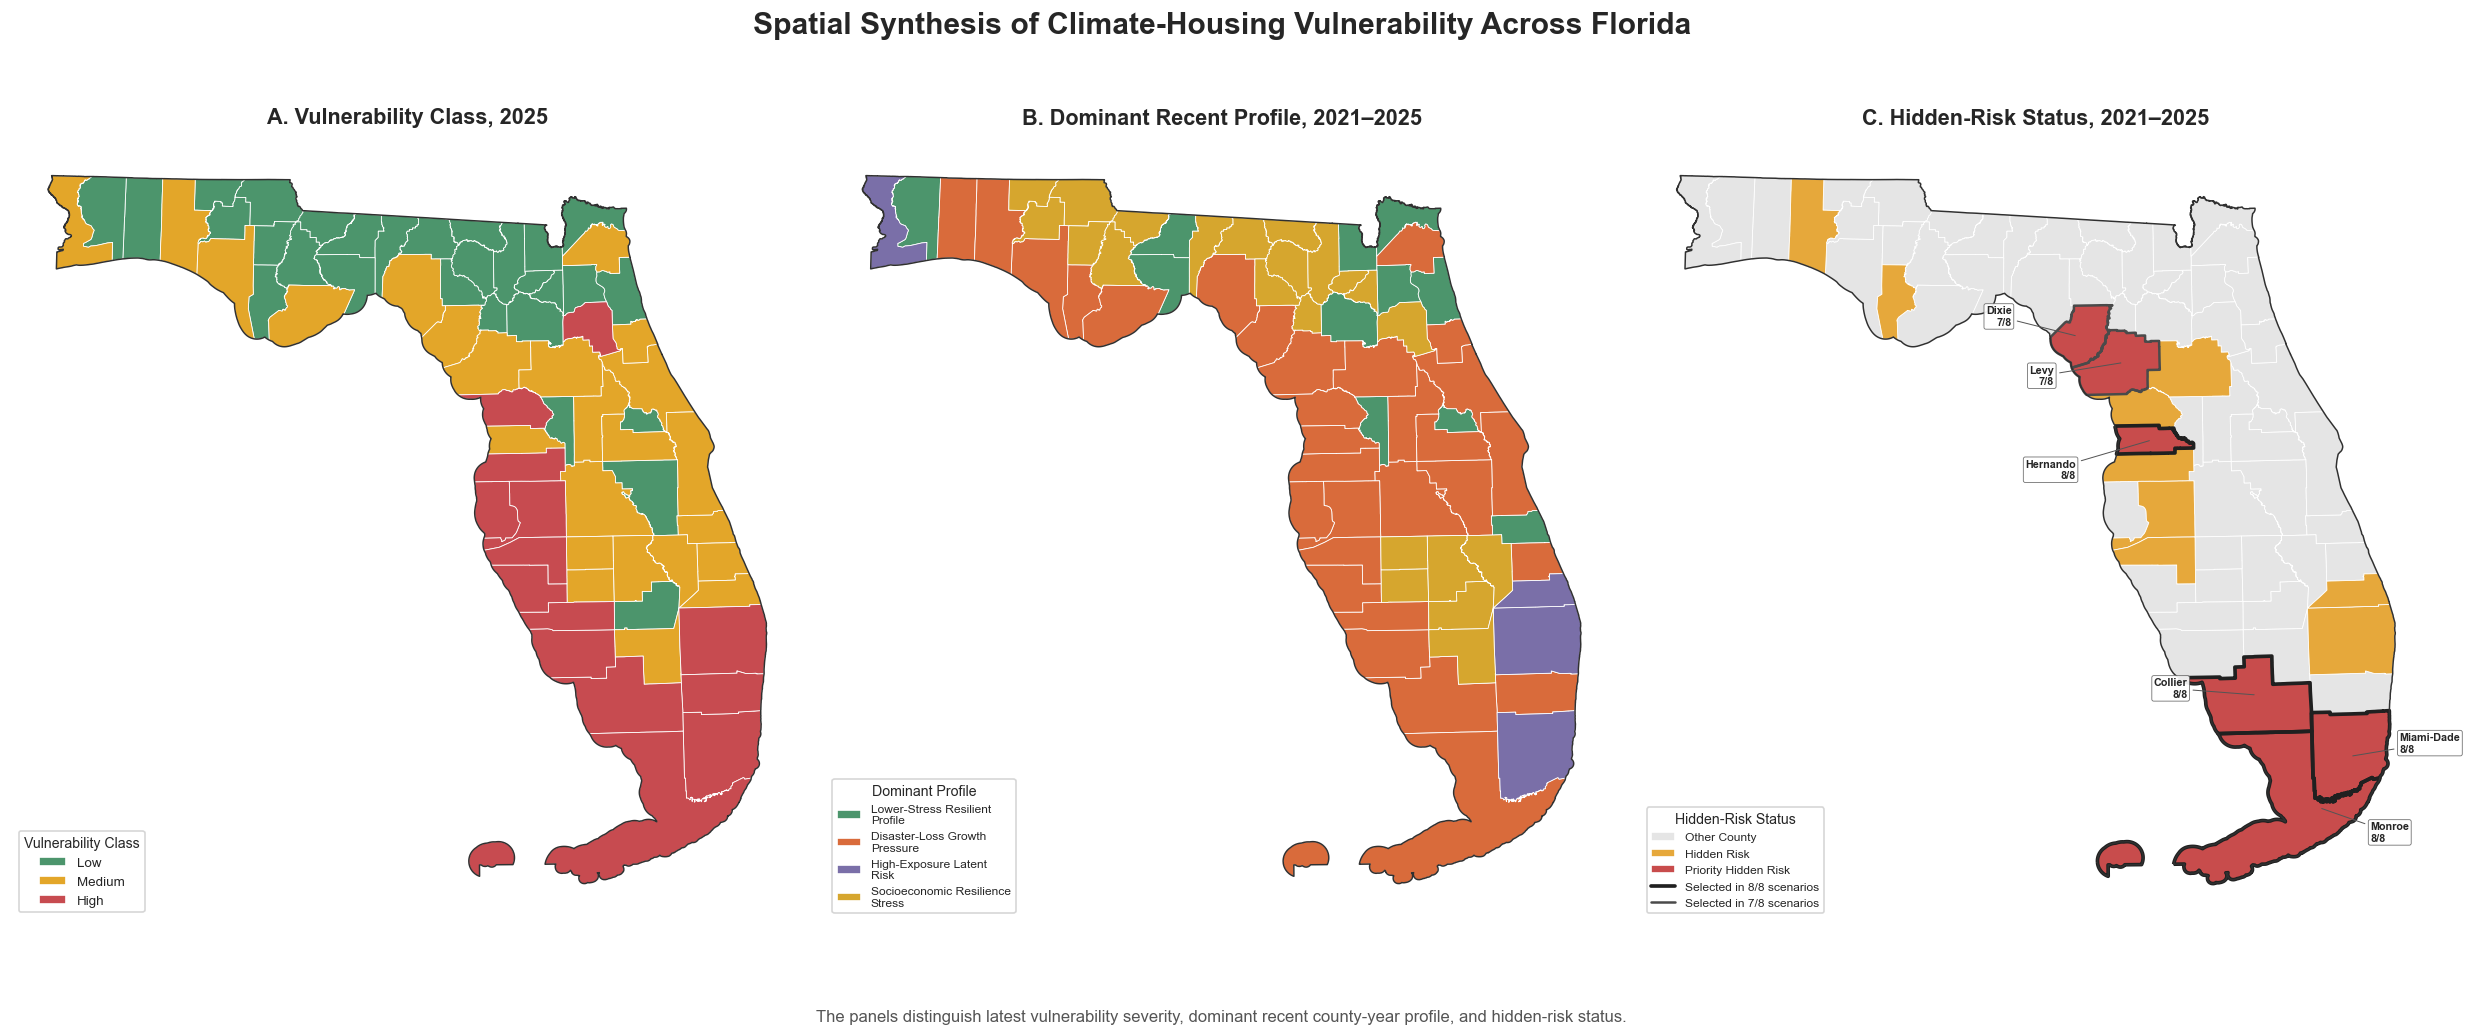

Final spatial-synthesis figure created.
Saved to: ..\results\figures\final_spatial_synthesis\florida_final_spatial_synthesis_panel.png


In [10]:
# ==================================================
# Step 10: Final Spatial Synthesis
# ==================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(21, 9)
)

fig.patch.set_facecolor("white")


# ==================================================
# Panel A: 2025 Vulnerability Class
# ==================================================

ax = axes[0]

for vulnerability_class in vulnerability_order:

    panel_data = final_spatial_data[
        final_spatial_data[
            "latest_vulnerability_class"
        ] == vulnerability_class
    ]

    panel_data.plot(
        ax=ax,
        color=vulnerability_colors[vulnerability_class],
        edgecolor="white",
        linewidth=0.5
    )

final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=0.9
)

ax.set_title(
    "A. Vulnerability Class, 2025",
    fontsize=13,
    fontweight="bold",
    pad=10
)

vulnerability_panel_legend = [
    Patch(
        facecolor=vulnerability_colors[category],
        edgecolor="white",
        label=category
    )
    for category in vulnerability_order
]

ax.legend(
    handles=vulnerability_panel_legend,
    title="Vulnerability Class",
    loc="lower left",
    frameon=True,
    fontsize=8,
    title_fontsize=8.5
)

ax.set_axis_off()


# ==================================================
# Panel B: Dominant Recent Profile
# ==================================================

ax = axes[1]

for profile_name in profile_order:

    panel_data = final_spatial_data[
        final_spatial_data[
            "dominant_recent_cluster_name"
        ] == profile_name
    ]

    panel_data.plot(
        ax=ax,
        color=profile_colors[profile_name],
        edgecolor="white",
        linewidth=0.5
    )

final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=0.9
)

ax.set_title(
    "B. Dominant Recent Profile, 2021–2025",
    fontsize=13,
    fontweight="bold",
    pad=10
)

profile_panel_legend = [
    Patch(
        facecolor=profile_colors[profile_name],
        edgecolor="white",
        label=profile_legend_labels[profile_name]
    )
    for profile_name in profile_order
]

ax.legend(
    handles=profile_panel_legend,
    title="Dominant Profile",
    loc="lower left",
    frameon=True,
    fontsize=7.2,
    title_fontsize=8.5
)

ax.set_axis_off()


# ==================================================
# Panel C: Hidden-Risk Status
# ==================================================

ax = axes[2]

for category in hidden_risk_order:

    panel_data = final_spatial_data[
        final_spatial_data[
            "hidden_risk_category"
        ] == category
    ]

    panel_data.plot(
        ax=ax,
        color=hidden_risk_colors[category],
        edgecolor="white",
        linewidth=0.5
    )

selected_all_eight.boundary.plot(
    ax=ax,
    color="#202020",
    linewidth=2.2
)

selected_seven.boundary.plot(
    ax=ax,
    color="#4A4A4A",
    linewidth=1.5
)

final_spatial_data.dissolve().boundary.plot(
    ax=ax,
    color="#303030",
    linewidth=0.9
)

ax.set_title(
    "C. Hidden-Risk Status, 2021–2025",
    fontsize=13,
    fontweight="bold",
    pad=10
)


# --------------------------------------------------
# Priority-County Labels
# --------------------------------------------------

panel_label_offsets = {
    "Dixie": (-40, 12),
    "Levy": (-42, -8),
    "Hernando": (-46, -18),
    "Collier": (-42, 4),
    "Miami-Dade": (30, 8),
    "Monroe": (31, -15)
}

panel_priority_points = priority_counties.copy()
panel_priority_points["label_geometry"] = (
    panel_priority_points.geometry.representative_point()
)

for _, row in panel_priority_points.iterrows():

    county_label = row["label_name"]
    label_point = row["label_geometry"]
    offset = panel_label_offsets.get(
        county_label,
        (28, 8)
    )

    ax.annotate(
        text=(
            f"{county_label}\n"
            f"{int(row['scenarios_selected'])}/8"
        ),
        xy=(label_point.x, label_point.y),
        xytext=offset,
        textcoords="offset points",
        fontsize=6.5,
        fontweight="bold",
        ha="left" if offset[0] > 0 else "right",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "#666666",
            "linewidth": 0.5,
            "alpha": 0.92
        },
        arrowprops={
            "arrowstyle": "-",
            "color": "#555555",
            "linewidth": 0.6
        }
    )


hidden_risk_panel_legend = [
    Patch(
        facecolor=hidden_risk_colors["Other County"],
        edgecolor="white",
        label="Other County"
    ),
    Patch(
        facecolor=hidden_risk_colors["Hidden Risk"],
        edgecolor="white",
        label="Hidden Risk"
    ),
    Patch(
        facecolor=hidden_risk_colors["Priority Hidden Risk"],
        edgecolor="white",
        label="Priority Hidden Risk"
    ),
    Line2D(
        [0],
        [0],
        color="#202020",
        linewidth=2.2,
        label="Selected in 8/8 scenarios"
    ),
    Line2D(
        [0],
        [0],
        color="#4A4A4A",
        linewidth=1.5,
        label="Selected in 7/8 scenarios"
    )
]

ax.legend(
    handles=hidden_risk_panel_legend,
    title="Hidden-Risk Status",
    loc="lower left",
    frameon=True,
    fontsize=7.2,
    title_fontsize=8.5
)

ax.set_axis_off()


# ==================================================
# Overall Figure Formatting
# ==================================================

fig.suptitle(
    "Spatial Synthesis of Climate-Housing "
    "Vulnerability Across Florida",
    fontsize=18,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.035,
    (
        "The panels distinguish latest vulnerability severity, "
        "dominant recent county-year profile, and hidden-risk status."
    ),
    ha="center",
    fontsize=10,
    color="#555555"
)

plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.90,
    bottom=0.08,
    wspace=0.03
)


# ==================================================
# Save Figure
# ==================================================

spatial_synthesis_path = (
    RESULTS_FIGURES
    / "florida_final_spatial_synthesis_panel.png"
)

plt.savefig(
    spatial_synthesis_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Final spatial-synthesis figure created.")
print(f"Saved to: {spatial_synthesis_path}")

## 11. Export Final Spatial Outputs

Save the final county-level spatial dataset and matching audit for reporting and reproducibility.

In [11]:
# ==================================================
# Step 11: Export Final Spatial Outputs
# ==================================================

# --------------------------------------------------
# Prepare Final County-Level Table
# --------------------------------------------------

final_county_spatial_table = (
    final_spatial_data
    .drop(columns="geometry")
    .sort_values("county_name")
    .reset_index(drop=True)
)


# ==================================================
# Define Export Paths
# ==================================================

final_spatial_csv_path = (
    RESULTS_TABLES
    / "final_county_spatial_synthesis.csv"
)

final_spatial_gpkg_path = (
    RESULTS_TABLES
    / "final_county_spatial_synthesis.gpkg"
)

matching_audit_path = (
    RESULTS_TABLES
    / "final_spatial_merge_audit.csv"
)


# ==================================================
# Save Tabular Outputs
# ==================================================

final_county_spatial_table.to_csv(
    final_spatial_csv_path,
    index=False
)

county_matching_audit.to_csv(
    matching_audit_path,
    index=False
)


# ==================================================
# Save Geometry-Enabled Spatial Layer
# ==================================================

if final_spatial_gpkg_path.exists():
    final_spatial_gpkg_path.unlink()

final_spatial_data.to_file(
    final_spatial_gpkg_path,
    layer="final_county_spatial_synthesis",
    driver="GPKG"
)


# ==================================================
# Export Summary
# ==================================================

export_summary = pd.DataFrame({
    "output": [
        "Final county spatial synthesis table",
        "Final county spatial GeoPackage",
        "Final spatial merge audit",
        "Final hidden-risk county summary"
    ],
    "rows": [
        len(final_county_spatial_table),
        len(final_spatial_data),
        len(county_matching_audit),
        len(hidden_risk_summary)
    ],
    "file": [
        final_spatial_csv_path.name,
        final_spatial_gpkg_path.name,
        matching_audit_path.name,
        hidden_risk_summary_path.name
    ]
})

print("Final spatial outputs exported successfully.")
print(f"Tables folder: {RESULTS_TABLES}")

display(export_summary)

Final spatial outputs exported successfully.
Tables folder: ..\results\tables\final_spatial_synthesis


,output,rows,file
0,Final county spatial synthesis table,67,final_county_spatial_synthesis.csv
1,Final county spatial GeoPackage,67,final_county_spatial_synthesis.gpkg
2,Final spatial merge audit,5,final_spatial_merge_audit.csv
3,Final hidden-risk county summary,15,final_hidden_risk_county_summary.csv


## 12. Spatial Synthesis

The three maps provide complementary views of Florida’s climate-housing vulnerability.

The 2025 class map shows the latest vulnerability severity, while the dominant-profile map shows the recurring form of county-year vulnerability during 2021–2025. The hidden-risk map identifies counties where strong recent housing growth coincided with persistent risk-oriented conditions.

Fifteen counties met the hidden-risk criteria, including six priority counties. Hernando, Collier, Monroe, and Miami-Dade were selected in all eight sensitivity scenarios, while Dixie and Levy were selected in seven.

Together, the spatial results show that similar vulnerability levels can reflect different combinations of exposure, disaster losses, socioeconomic stress, affordability pressure, resilience, and housing-market conditions.

## 13. Final Conclusion

Florida’s climate-housing vulnerability was spatially uneven and reflected multiple vulnerability pathways rather than one uniform pattern.

The final results showed that strong housing-market performance did not necessarily indicate lower vulnerability. Fifteen counties combined strong recent price growth with persistent risk-oriented conditions, including six priority counties: Hernando, Collier, Monroe, Miami-Dade, Dixie, and Levy.

Hernando, Collier, Monroe, and Miami-Dade were selected in all eight sensitivity scenarios, while Dixie and Levy were selected in seven. These results provide the strongest evidence that recent market growth can coexist with climate exposure, disaster losses, affordability pressure, socioeconomic stress, insurance burden, and resilience constraints.

Overall, the project demonstrates the value of combining classification, clustering, explainability, sensitivity analysis, and spatial mapping when identifying hidden climate-housing vulnerability.